# KI Projekt Gruppe 310 – Zusammenfassung
**Modul:** Künstliche Intelligenz I | **Abgabe:** 15.04.2026

Komprimierte, lauffähige Zusammenfassung des Originalprojekts. Redundante Visualisierungen wurden zusammengeführt; alle Ergebnisse bleiben erhalten.

**Struktur:**
1. [Imports & Datenladen](#teil1)
2. [EDA & Preprocessing](#teil2)
3. [Baseline-Modelle](#teil3)
4. [Keras MLP – Architektur & Hyperparameter-Tuning](#teil4)
5. [Evaluation & Finaler Vergleich](#teil5)
6. [Finales Modell & Deployment](#teil6)

---

<a id='teil1'></a>
## Teil 1 – Imports & Datenladen
Alle Bibliotheken sowie der California Housing Datensatz werden geladen.  
**Datensatz:** 20.640 Instanzen | 8 numerische Features | Zielvariable: `MedHouseVal` (Median-Hauswert in $100.000)

In [8]:
# == IMPORTS ==
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, joblib
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

print(f'Bibliotheken geladen | TensorFlow {tf.__version__}')

# == DATEN LADEN ==
california_housing = fetch_california_housing(as_frame=True)
df = california_housing.frame
X  = df.drop('MedHouseVal', axis=1)   # 8 Features
y  = df['MedHouseVal']                 # Zielvariable
feature_names = X.columns.tolist()

print(f'Datensatz: {len(df):,} Instanzen | {X.shape[1]} Features')
print(f'Zielvariable MedHouseVal: Min=${y.min()*100000:.0f} | Max=${y.max()*100000:.0f} | Mean=${y.mean()*100000:.0f}')
print(f'Features: {feature_names}')

Bibliotheken geladen | TensorFlow 2.20.0
Datensatz: 20,640 Instanzen | 8 Features
Zielvariable MedHouseVal: Min=$14999 | Max=$500001 | Mean=$206856
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


<a id='teil2'></a>
## Teil 2 – EDA & Preprocessing

**EDA-Erkenntnisse:**
- Keine fehlenden Werte oder Duplikate
- Stärkster Prädiktor: `MedInc` (r = +0.688)
- Hauspreise und Einkommen rechtsschief; Population mit extremen Ausreißern

**Preprocessing-Schritte:**
1. Train-Test-Split 80/20 (`random_state=42`)
2. Ausreißerentfernung via IQR (Faktor 3.0) **nur auf Trainingsdaten** (~1.002 Instanzen entfernt)
3. StandardScaler (Z-Score) – Fit nur auf Training, Transform auf beide (kein Data Leakage)

DATENSATZ-UEBERSICHT:
  Instanzen: 20,640 | Features: 8 | Fehlende Werte: 0
  Duplikate: 0

Korrelationen mit MedHouseVal:
  MedInc         : +0.6881
  AveRooms       : +0.1519
  HouseAge       : +0.1056
  AveOccup       : -0.0237
  Population     : -0.0246
  Longitude      : -0.0460
  AveBedrms      : -0.0467
  Latitude       : -0.1442


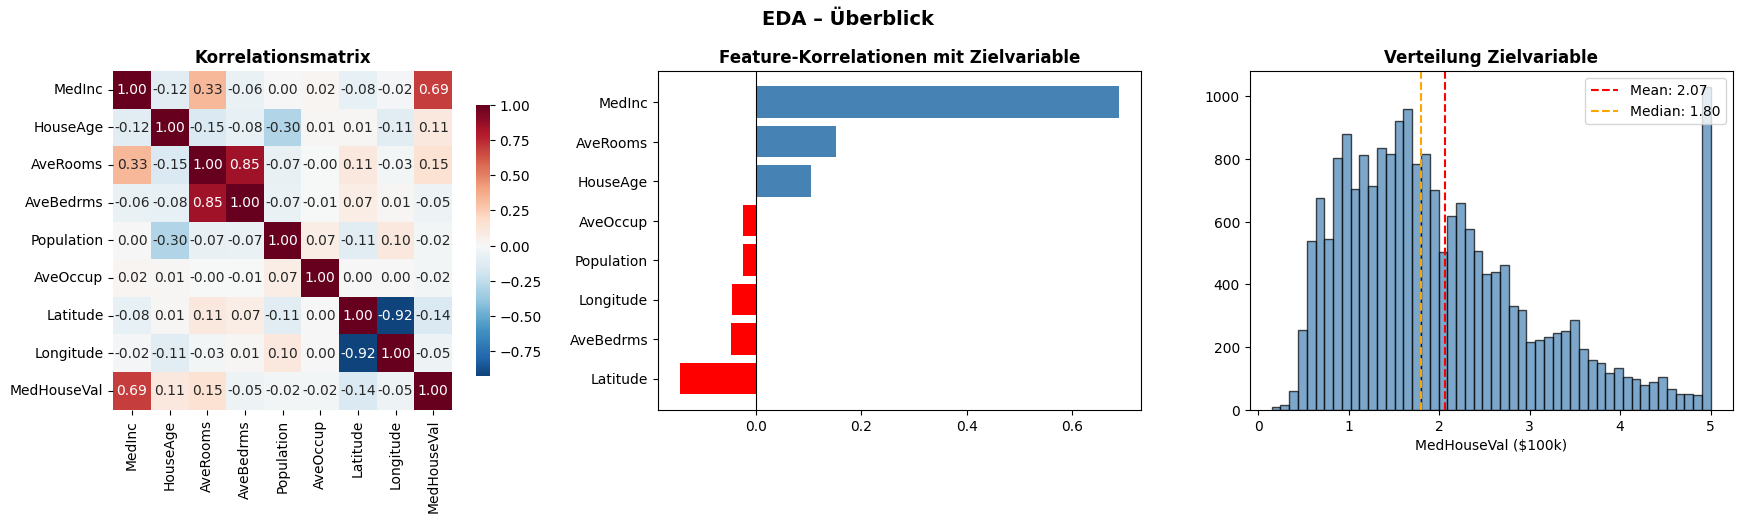


Outlier-Analyse (IQR, Faktor 1.5):
  MedInc         :   681 Ausreisser (3.3%)
  HouseAge       :     0 Ausreisser (0.0%)
  AveRooms       :   511 Ausreisser (2.5%)
  AveBedrms      :  1424 Ausreisser (6.9%)
  Population     :  1196 Ausreisser (5.8%)
  AveOccup       :   711 Ausreisser (3.4%)
  Latitude       :     0 Ausreisser (0.0%)
  Longitude      :     0 Ausreisser (0.0%)


In [9]:
# == EDA: DATENQUALITAET & KORRELATIONEN ==
print('DATENSATZ-UEBERSICHT:')
print(f'  Instanzen: {len(df):,} | Features: {X.shape[1]} | Fehlende Werte: {df.isnull().sum().sum()}')
print(f'  Duplikate: {df.duplicated().sum()}')

print('\nKorrelationen mit MedHouseVal:')
corrs = df.corr()['MedHouseVal'].drop('MedHouseVal').sort_values(ascending=False)
for feat, val in corrs.items():
    print(f'  {feat:<15}: {val:+.4f}')

# Visualisierung
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('EDA – Überblick', fontsize=14, fontweight='bold')

corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
            square=True, ax=axes[0], fmt='.2f', cbar_kws={'shrink': 0.8})
axes[0].set_title('Korrelationsmatrix', fontweight='bold')

corrs_sorted = corr_matrix['MedHouseVal'].drop('MedHouseVal').sort_values()
colors_bar = ['red' if v < 0 else 'steelblue' for v in corrs_sorted]
axes[1].barh(corrs_sorted.index, corrs_sorted.values, color=colors_bar)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Feature-Korrelationen mit Zielvariable', fontweight='bold')

axes[2].hist(y, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[2].axvline(y.mean(),   color='red',    linestyle='--', label=f'Mean: {y.mean():.2f}')
axes[2].axvline(y.median(), color='orange', linestyle='--', label=f'Median: {y.median():.2f}')
axes[2].set_xlabel('MedHouseVal ($100k)')
axes[2].set_title('Verteilung Zielvariable', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_uebersicht.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nOutlier-Analyse (IQR, Faktor 1.5):')
for feature in feature_names:
    Q1, Q3 = df[feature].quantile(0.25), df[feature].quantile(0.75)
    n_out = ((df[feature] < Q1 - 1.5*(Q3-Q1)) | (df[feature] > Q3 + 1.5*(Q3-Q1))).sum()
    print(f'  {feature:<15}: {n_out:>5} Ausreisser ({n_out/len(df)*100:.1f}%)')

In [10]:
# == TRAIN-TEST-SPLIT ==
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,} Instanzen')

# == OUTLIER-ENTFERNUNG (nur Trainingsdaten, IQR Faktor 3.0) ==
def remove_outliers_iqr(X_df, y_series, features_to_check, factor=3.0):
    """Entfernt extreme Ausreisser aus dem Trainingsset. Testset bleibt unveraendert."""
    mask = np.ones(len(X_df), dtype=bool)
    for feat in features_to_check:
        Q1, Q3 = X_df[feat].quantile(0.25), X_df[feat].quantile(0.75)
        IQR = Q3 - Q1
        mask &= (X_df[feat] >= Q1 - factor*IQR) & (X_df[feat] <= Q3 + factor*IQR)
    return X_df[mask].reset_index(drop=True), y_series[mask].reset_index(drop=True)

X_train_clean, y_train_clean = remove_outliers_iqr(
    X_train, y_train, ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']
)
print(f'Nach Outlier-Entfernung: {len(X_train_clean):,} Instanzen ({len(X_train)-len(X_train_clean)} entfernt)')

# == FEATURE-SKALIERUNG (StandardScaler) ==
# WICHTIG: fit() nur auf Trainingsdaten -> kein Data Leakage!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)  # fit + transform
X_test_scaled  = scaler.transform(X_test)              # nur transform

print(f'Skalierung abgeschlossen | X_train_scaled: {X_train_scaled.shape} | X_test_scaled: {X_test_scaled.shape}')

Train: 16,512 | Test: 4,128 Instanzen
Nach Outlier-Entfernung: 15,510 Instanzen (1002 entfernt)
Skalierung abgeschlossen | X_train_scaled: (15510, 8) | X_test_scaled: (4128, 8)


<a id='teil3'></a>
## Teil 3 – Baseline-Modelle

Sechs klassische ML-Modelle werden mit **3-Fold Cross-Validation** trainiert.  

| Modell | Test R² | Bewertung |
|--------|---------|----------|
| Random Forest (n=50) | ~0.804 | Bestes Baseline-Modell |
| Gradient Boosting (n=50) | ~0.741 | Sehr gut |
| Lasso Regression | ~0.395 | Mittel |
| Lineare / Ridge Regression | ~0.125 | Schwach |

In [11]:
# == ALLE BASELINE-MODELLE DEFINIEREN & TRAINIEREN ==
models = {
    'Lineare Regression':  LinearRegression(),
    'Ridge Regression':    Ridge(alpha=1.0),
    'Lasso Regression':    Lasso(alpha=0.1, max_iter=2000),
    'Random Forest':       RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingRegressor(n_estimators=50, random_state=42),
    'MLP (sklearn)':       MLPRegressor(hidden_layer_sizes=(100, 50, 25), activation='relu',
                                        learning_rate_init=0.001, max_iter=1000,
                                        alpha=0.01, random_state=42),
}

model_results = {}
print(f'{"Modell":<32} {"CV R2":>8} {"Test R2":>9} {"RMSE":>9} {"MAE":>9}')
print('-' * 70)

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_scaled, y_train_clean, cv=3, scoring='r2')
    model.fit(X_train_scaled, y_train_clean)
    y_pred = model.predict(X_test_scaled)
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    model_results[name] = {
        'CV_R2_mean': cv_scores.mean(), 'CV_R2_std': cv_scores.std(),
        'Test_R2': r2, 'RMSE': rmse, 'MAE': mae, 'predictions': y_pred
    }
    print(f'{name:<32} {cv_scores.mean():>8.4f} {r2:>9.4f} {rmse:>9.4f} {mae:>9.4f}')

print('-' * 70)
lin_r2 = model_results['Lineare Regression']['Test_R2']

Modell                              CV R2   Test R2      RMSE       MAE
----------------------------------------------------------------------
Lineare Regression                 0.6780    0.1253    1.0706    0.5364
Ridge Regression                   0.6780    0.1255    1.0705    0.5364
Lasso Regression                   0.5611    0.3948    0.8906    0.6014
Random Forest                      0.8084    0.8035    0.5074    0.3285
Gradient Boosting                  0.7645    0.7413    0.5822    0.4054
MLP (sklearn)                      0.7721    0.2373    0.9998    0.4111
----------------------------------------------------------------------


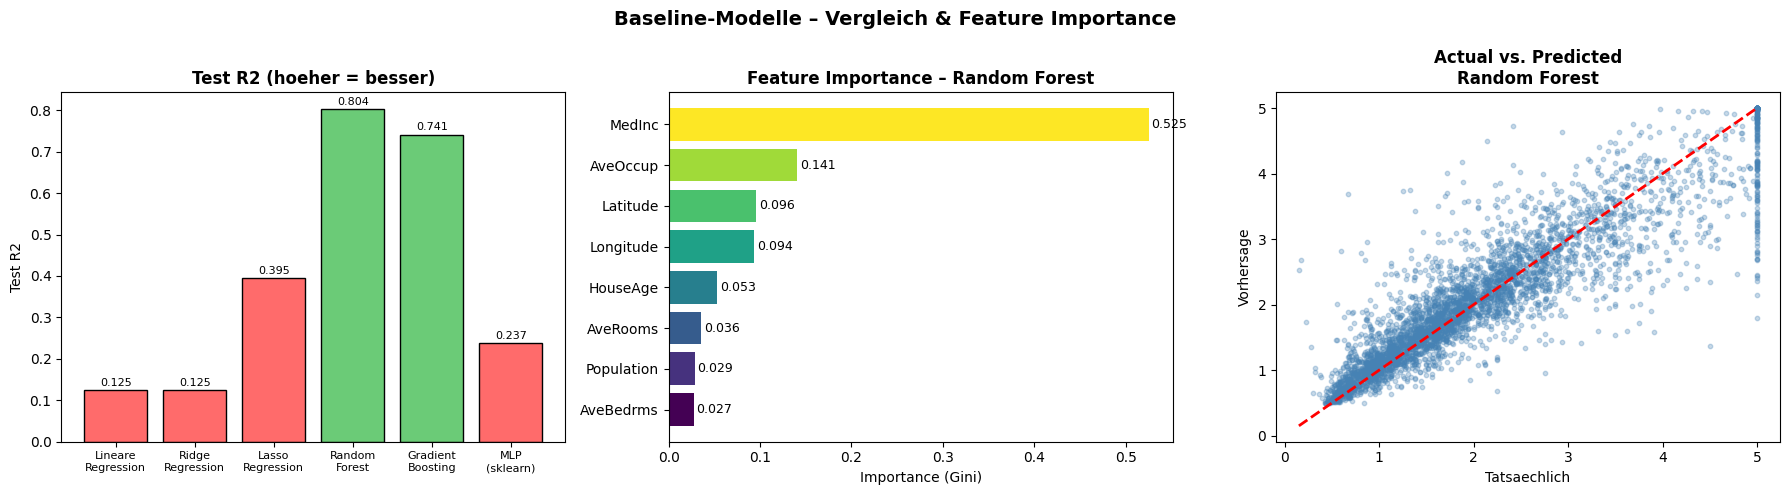

Bestes Baseline-Modell: Random Forest | R2=0.8035
Wichtigstes Feature: MedInc (52.5%)


In [12]:
# == FEATURE IMPORTANCE (Random Forest) & MODELLVERGLEICH ==
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Baseline-Modelle – Vergleich & Feature Importance', fontsize=14, fontweight='bold')

model_names = list(model_results.keys())
test_r2 = [model_results[m]['Test_R2'] for m in model_names]
bar_colors = ['#ff6b6b' if v < 0.5 else '#ffd93d' if v < 0.7 else '#6bcb77' for v in test_r2]
axes[0].bar([n.replace(' ', '\n') for n in model_names], test_r2, color=bar_colors, edgecolor='black')
axes[0].set_ylabel('Test R2')
axes[0].set_title('Test R2 (hoeher = besser)', fontweight='bold')
axes[0].tick_params(axis='x', labelsize=8)
for i, v in enumerate(test_r2):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)

rf_model = models['Random Forest']
fi = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values()
axes[1].barh(fi.index, fi.values, color=plt.cm.viridis(np.linspace(0, 1, len(fi))))
axes[1].set_xlabel('Importance (Gini)')
axes[1].set_title('Feature Importance – Random Forest', fontweight='bold')
for i, (val, fname) in enumerate(zip(fi.values, fi.index)):
    axes[1].text(val + 0.003, i, f'{val:.3f}', va='center', fontsize=9)

best_base = max(model_results, key=lambda k: model_results[k]['Test_R2'])
axes[2].scatter(y_test, model_results[best_base]['predictions'], alpha=0.3, s=10, color='steelblue')
lim = [y_test.min(), y_test.max()]
axes[2].plot(lim, lim, 'r--', linewidth=2)
axes[2].set_xlabel('Tatsaechlich'); axes[2].set_ylabel('Vorhersage')
axes[2].set_title(f'Actual vs. Predicted\n{best_base}', fontweight='bold')

plt.tight_layout()
plt.savefig('baseline_vergleich.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Bestes Baseline-Modell: {best_base} | R2={model_results[best_base]["Test_R2"]:.4f}')
print(f'Wichtigstes Feature: {fi.idxmax()} ({fi.max()*100:.1f}%)')

<a id='teil4'></a>
## Teil 4 – Keras MLP: Architektur & Hyperparameter-Tuning

**Modell:** `Input(8) → Dense(n, act) x depth → Dense(1, linear)`  
**Optimierer:** SGD mit `clipnorm=1.0` (verhindert NaN durch explodierende Gradienten)  
**Regularisierung:** `EarlyStopping(patience=10, restore_best_weights=True)`

| Hyperparameter | Getestete Werte | Bester Wert |
|----------------|----------------|-------------|
| Netztiefe | 1, 2, 3, 4 | aus Suche |
| Learning Rate | 0.1, 0.01, 0.001, 0.0001 | 0.1 |
| Aktivierung | relu, sigmoid | sigmoid |
| Batch-Größe | 16, 32, 64, 128 | 16 |
| Architektur | [64,64], [64,128], [128,64], [128,128] | [64,64] |
| Dropout | 0.0, 0.1, 0.2 | 0.0 |

In [13]:
# == MODELL-FABRIK ==
def create_nn_model(neurons_list=[64, 64], dropout_rate=0.0,
                    learning_rate=0.001, activation='relu'):
    """
    Erstellt ein flexibles Keras Sequential Modell fuer Regression.
    neurons_list  - Neuronenanzahl pro Hidden Layer, z.B. [128, 64]
    dropout_rate  - Dropout-Rate (0.0 = deaktiviert)
    learning_rate - SGD-Lernrate
    activation    - Aktivierungsfunktion ('relu' oder 'sigmoid')
    """
    model = keras.Sequential()
    # Expliziter Input-Layer (verhindert Keras UserWarning)
    model.add(layers.Input(shape=(X_train_scaled.shape[1],)))
    for n in neurons_list:
        model.add(layers.Dense(n, activation=activation))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))
    # Output-Layer: linear -> Pflicht bei Regressionsproblemen
    model.add(layers.Dense(1, activation='linear'))
    # SGD mit clipnorm=1.0 verhindert explodierende Gradienten (NaN)
    optimizer = keras.optimizers.SGD(learning_rate=learning_rate, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

def train_nn_model(model, X_tr, y_tr, X_val, y_val, batch_size=32, epochs=100):
    """Trainiert mit Early Stopping (patience=10, restore_best_weights=True)."""
    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    return model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
                     epochs=epochs, batch_size=batch_size,
                     callbacks=[early_stop], verbose=0)

print('create_nn_model() und train_nn_model() definiert')

create_nn_model() und train_nn_model() definiert


In [14]:
# == HYPERPARAMETER-SUCHE: Netztiefe x Learning Rate x Aktivierung ==
# Internes Validierungsset (20%) - Testset bleibt unberuehrt (kein Data Leakage)!
X_tr_hp, X_val_hp, y_tr_hp, y_val_hp = train_test_split(
    X_train_scaled, y_train_clean, test_size=0.2, random_state=42
)

depths, learning_rates, activations = [1, 2, 3, 4], [0.1, 0.01, 0.001, 0.0001], ['relu', 'sigmoid']
hp_results, best_rmse_hp, best_config = [], float('inf'), {}

print(f'{"Depth":<8} {"LR":<8} {"Act":<10} {"RMSE":<10}')
print('-' * 40)

for depth in depths:
    for lr in learning_rates:
        for act in activations:
            try:
                model = create_nn_model([64]*depth, learning_rate=lr, activation=act)
                train_nn_model(model, X_tr_hp, y_tr_hp, X_val_hp, y_val_hp)
                preds = model.predict(X_test_scaled, verbose=0)
                if np.isnan(preds).any():
                    continue
                rmse = np.sqrt(mean_squared_error(y_test, preds))
                hp_results.append({'depth': depth, 'lr': lr, 'act': act, 'rmse': rmse})
                print(f'{depth:<8} {lr:<8} {act:<10} {rmse:.4f}')
                if rmse < best_rmse_hp:
                    best_rmse_hp = rmse
                    best_config  = {'depth': depth, 'lr': lr, 'act': act}
            except Exception as e:
                print(f'  Depth={depth} LR={lr} {act}: ERROR - {e}')

print(f'\nBestes Ergebnis: RMSE={best_rmse_hp:.4f} | {best_config}')

Depth    LR       Act        RMSE      
----------------------------------------
1        0.1      relu       0.8532
1        0.1      sigmoid    0.6313
1        0.01     relu       0.6414
1        0.01     sigmoid    0.6220
1        0.001    relu       0.7964
1        0.001    sigmoid    0.6705
1        0.0001   relu       1.8842
1        0.0001   sigmoid    0.7772
2        0.1      relu       0.9404
2        0.1      sigmoid    0.5464
2        0.01     relu       0.7328
2        0.01     sigmoid    0.6103
2        0.001    relu       0.6024
2        0.001    sigmoid    0.6780
2        0.0001   relu       1.3450
2        0.0001   sigmoid    1.0236
3        0.1      relu       0.9712
3        0.1      sigmoid    0.5695
3        0.01     relu       0.6816
3        0.01     sigmoid    0.6139
3        0.001    relu       0.7853
3        0.001    sigmoid    0.6876
3        0.0001   relu       1.2420
3        0.0001   sigmoid    1.1315
4        0.1      relu       0.9315
4        0.1      s

In [15]:
# == BATCH-GROESSE, ARCHITEKTUR & DROPOUT TUNING ==
fixed_lr  = best_config.get('lr', 0.1)
fixed_act = best_config.get('act', 'sigmoid')

# Batch-Groesse
batch_results, best_batch, best_batch_rmse = [], 32, float('inf')
print('Batch-Groessen-Tuning:')
for bs in [16, 32, 64, 128]:
    model = create_nn_model([64, 64], learning_rate=fixed_lr, activation=fixed_act)
    train_nn_model(model, X_tr_hp, y_tr_hp, X_val_hp, y_val_hp, batch_size=bs)
    rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test_scaled, verbose=0)))
    batch_results.append({'batch_size': bs, 'rmse': rmse})
    print(f'  Batch {bs:>4} -> RMSE: {rmse:.4f}')
    if rmse < best_batch_rmse: best_batch_rmse, best_batch = rmse, bs
print(f'  Beste Batch-Groesse: {best_batch} (RMSE={best_batch_rmse:.4f})')

# Architektur
arch_results, best_arch, best_arch_rmse = [], [64, 64], float('inf')
print('\nArchitektur-Tuning:')
for arch in [[64,64], [64,128], [128,64], [128,128]]:
    model = create_nn_model(arch, learning_rate=fixed_lr, activation=fixed_act)
    train_nn_model(model, X_tr_hp, y_tr_hp, X_val_hp, y_val_hp, batch_size=best_batch)
    rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test_scaled, verbose=0)))
    arch_results.append({'architecture': str(arch), 'rmse': rmse})
    print(f'  {str(arch):<15} -> RMSE: {rmse:.4f}')
    if rmse < best_arch_rmse: best_arch_rmse, best_arch = rmse, arch
print(f'  Beste Architektur: {best_arch} (RMSE={best_arch_rmse:.4f})')

# Dropout
dropout_results, best_dropout, best_dropout_rmse = [], 0.0, float('inf')
final_keras_model = None
print('\nDropout-Tuning:')
for dp in [0.0, 0.1, 0.2]:
    model = create_nn_model(best_arch, learning_rate=fixed_lr, activation=fixed_act, dropout_rate=dp)
    train_nn_model(model, X_tr_hp, y_tr_hp, X_val_hp, y_val_hp, batch_size=best_batch)
    rmse = np.sqrt(mean_squared_error(y_test, model.predict(X_test_scaled, verbose=0)))
    dropout_results.append({'dropout': dp, 'rmse': rmse})
    print(f'  Dropout={dp} -> RMSE: {rmse:.4f}')
    if rmse < best_dropout_rmse:
        best_dropout_rmse, best_dropout, final_keras_model = rmse, dp, model
print(f'  Bestes Dropout: {best_dropout} (RMSE={best_dropout_rmse:.4f})')

Batch-Groessen-Tuning:
  Batch   16 -> RMSE: 0.5349
  Batch   32 -> RMSE: 0.5760
  Batch   64 -> RMSE: 0.5772
  Batch  128 -> RMSE: 0.5927
  Beste Batch-Groesse: 16 (RMSE=0.5349)

Architektur-Tuning:
  [64, 64]        -> RMSE: 0.5521
  [64, 128]       -> RMSE: 0.5950
  [128, 64]       -> RMSE: 0.5310
  [128, 128]      -> RMSE: 0.5393
  Beste Architektur: [128, 64] (RMSE=0.5310)

Dropout-Tuning:
  Dropout=0.0 -> RMSE: 0.5418
  Dropout=0.1 -> RMSE: 0.5845
  Dropout=0.2 -> RMSE: 0.5866
  Bestes Dropout: 0.0 (RMSE=0.5418)


Finale Konfiguration: Arch=[128, 64] | LR=0.1 | Act=sigmoid | Batch=16 | Dropout=0.0
Training abgeschlossen nach 79 Epochen


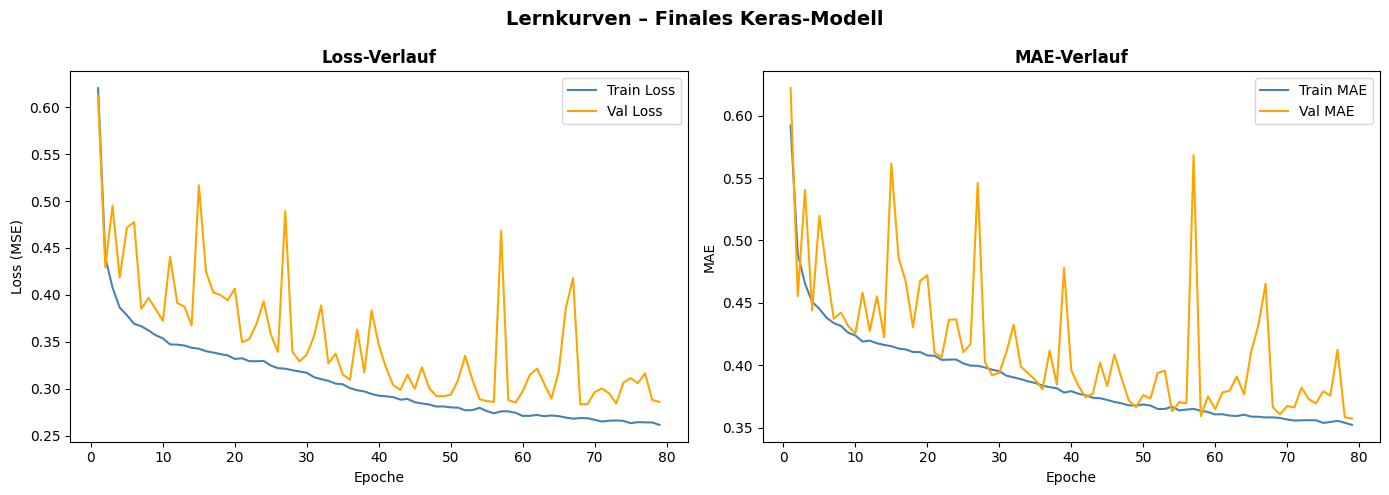

In [16]:
# == FINALES KERAS-MODELL (alle Trainingsdaten) ==
print(f'Finale Konfiguration: Arch={best_arch} | LR={fixed_lr} | Act={fixed_act} | Batch={best_batch} | Dropout={best_dropout}')

final_keras_model = create_nn_model(
    neurons_list=best_arch, learning_rate=fixed_lr,
    activation=fixed_act, dropout_rate=best_dropout
)
final_history = train_nn_model(
    final_keras_model,
    X_train_scaled, y_train_clean,  # komplette Trainingsdaten
    X_test_scaled,  y_test,          # Testset nur zum Monitoring
    batch_size=best_batch, epochs=200
)
print(f'Training abgeschlossen nach {len(final_history.history["loss"])} Epochen')

# Lernkurven
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Lernkurven – Finales Keras-Modell', fontsize=14, fontweight='bold')
epochs_r = range(1, len(final_history.history['loss'])+1)
axes[0].plot(epochs_r, final_history.history['loss'],     label='Train Loss', color='steelblue')
axes[0].plot(epochs_r, final_history.history['val_loss'], label='Val Loss',   color='orange')
axes[0].set_xlabel('Epoche'); axes[0].set_ylabel('Loss (MSE)'); axes[0].legend()
axes[0].set_title('Loss-Verlauf', fontweight='bold')
axes[1].plot(epochs_r, final_history.history['mae'],     label='Train MAE', color='steelblue')
axes[1].plot(epochs_r, final_history.history['val_mae'], label='Val MAE',   color='orange')
axes[1].set_xlabel('Epoche'); axes[1].set_ylabel('MAE'); axes[1].legend()
axes[1].set_title('MAE-Verlauf', fontweight='bold')
plt.tight_layout(); plt.savefig('lernkurven.png', dpi=150, bbox_inches='tight'); plt.show()

<a id='teil5'></a>
## Teil 5 – Evaluation & Finaler Vergleich

Alle Modelle werden auf dem **unberührten Testset** final bewertet.  
Zusätzlich: Residualanalyse (Keras MLP) und PCA.

In [17]:
# == KERAS MLP - METRIKEN AUF TESTSET ==
keras_preds = final_keras_model.predict(X_test_scaled, verbose=0).flatten()
keras_mae   = mean_absolute_error(y_test, keras_preds)
keras_rmse  = np.sqrt(mean_squared_error(y_test, keras_preds))
keras_r2    = r2_score(y_test, keras_preds)

print('\n' + '='*55)
print('FINALER MODELLVERGLEICH')
print('='*55)
print(f'{"Modell":<25} {"MAE":>8} {"RMSE":>8} {"R2":>8}')
print('-'*55)
for name, res in model_results.items():
    print(f'{name:<25} {res["MAE"]:>8.4f} {res["RMSE"]:>8.4f} {res["Test_R2"]:>8.4f}')
print(f'{"Keras MLP (optimiert)":<25} {keras_mae:>8.4f} {keras_rmse:>8.4f} {keras_r2:>8.4f}')
print('='*55)
improvement = (keras_r2 - lin_r2) / abs(lin_r2) * 100 if lin_r2 != 0 else float('inf')
print(f'Verbesserung Keras MLP vs. Lineare Regression: +{improvement:.1f}% R2')


FINALER MODELLVERGLEICH
Modell                         MAE     RMSE       R2
-------------------------------------------------------
Lineare Regression          0.5364   1.0706   0.1253
Ridge Regression            0.5364   1.0705   0.1255
Lasso Regression            0.6014   0.8906   0.3948
Random Forest               0.3285   0.5074   0.8035
Gradient Boosting           0.4054   0.5822   0.7413
MLP (sklearn)               0.4111   0.9998   0.2373
Keras MLP (optimiert)       0.3606   0.5327   0.7835
Verbesserung Keras MLP vs. Lineare Regression: +525.4% R2


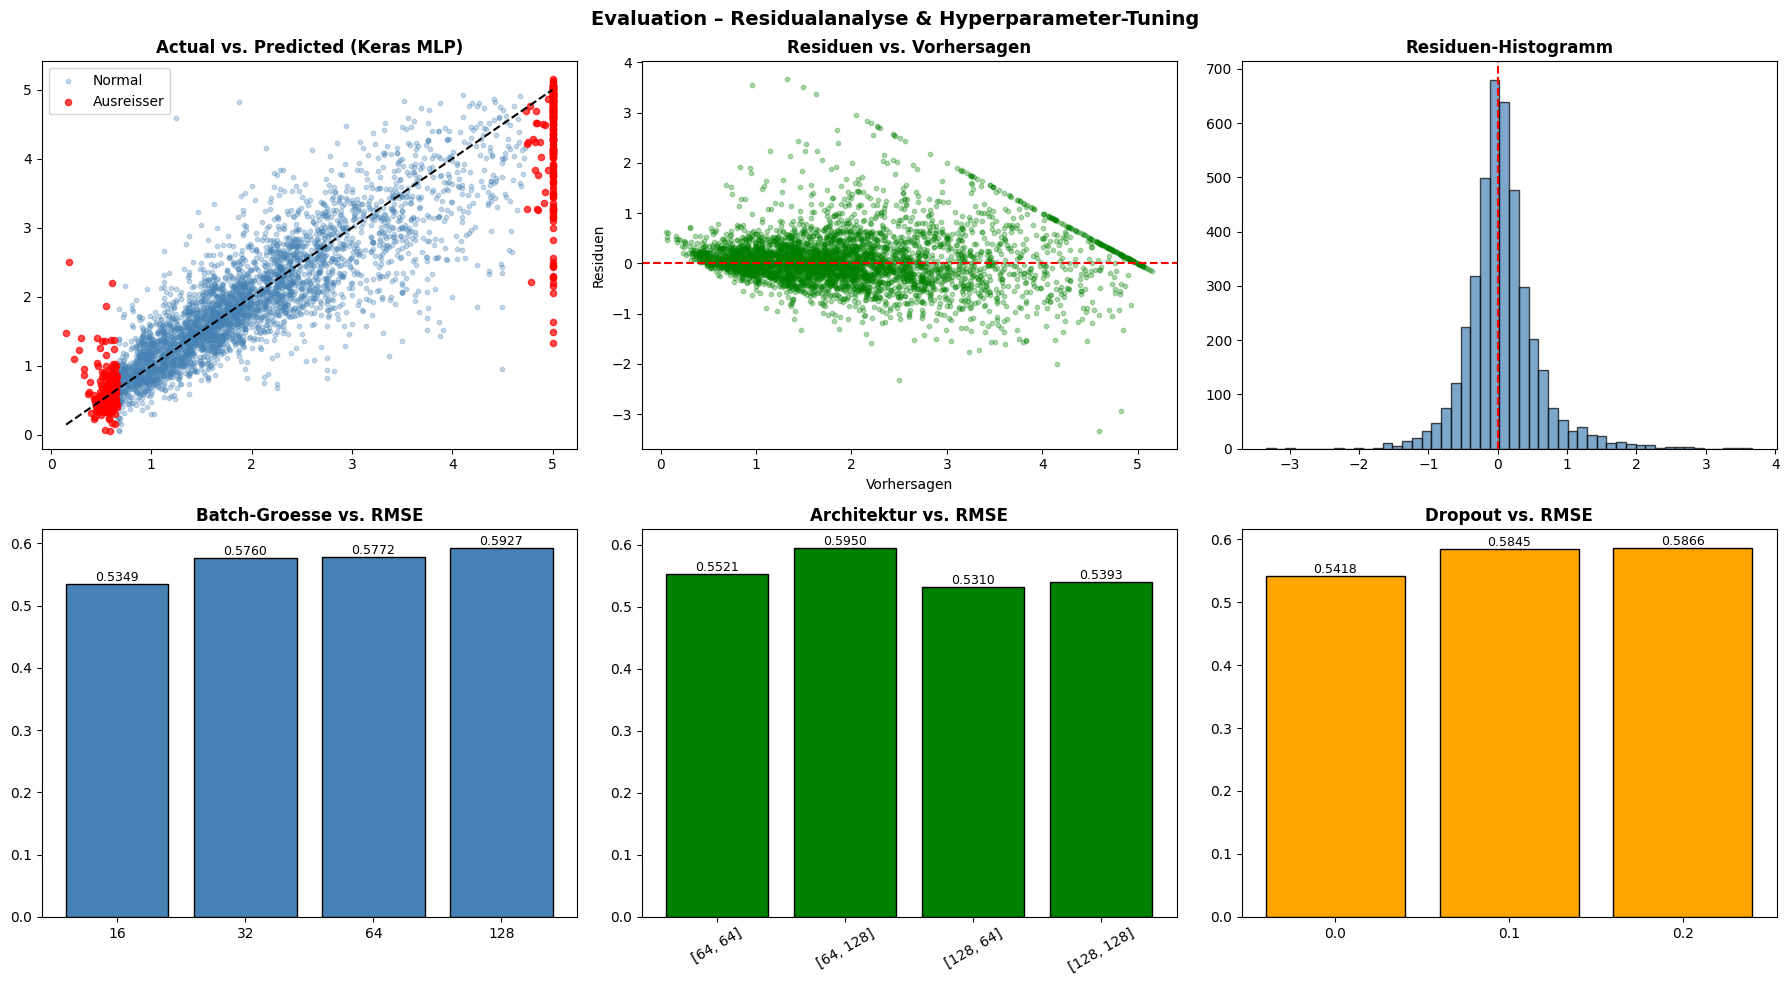

RMSE normale Preise: 0.4900 | RMSE Ausreisser: 0.8228
-> Modell ist bei extremen Preisen weniger praezise (erwartetes Verhalten)


In [18]:
# == RESIDUALANALYSE & HP-TUNING VISUALISIERUNG ==
residuals   = y_test.values - keras_preds
low_thresh  = np.percentile(y_test, 5)
high_thresh = np.percentile(y_test, 95)
mask_out    = (y_test.values < low_thresh) | (y_test.values > high_thresh)
mask_norm   = ~mask_out
rmse_norm   = np.sqrt(mean_squared_error(y_test.values[mask_norm], keras_preds[mask_norm]))
rmse_out    = np.sqrt(mean_squared_error(y_test.values[mask_out],  keras_preds[mask_out]))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Evaluation – Residualanalyse & Hyperparameter-Tuning', fontsize=14, fontweight='bold')

axes[0,0].scatter(y_test.values[mask_norm], keras_preds[mask_norm], alpha=0.3, s=10, c='steelblue', label='Normal')
axes[0,0].scatter(y_test.values[mask_out],  keras_preds[mask_out],  alpha=0.7, s=20, c='red',       label='Ausreisser')
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
axes[0,0].set_title('Actual vs. Predicted (Keras MLP)', fontweight='bold'); axes[0,0].legend()

axes[0,1].scatter(keras_preds, residuals, alpha=0.3, s=10, c='green')
axes[0,1].axhline(0, color='red', linestyle='--')
axes[0,1].set_xlabel('Vorhersagen'); axes[0,1].set_ylabel('Residuen')
axes[0,1].set_title('Residuen vs. Vorhersagen', fontweight='bold')

axes[0,2].hist(residuals, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0,2].axvline(0, color='red', linestyle='--')
axes[0,2].set_title('Residuen-Histogramm', fontweight='bold')

if batch_results:
    bs_df = pd.DataFrame(batch_results)
    axes[1,0].bar([str(x) for x in bs_df['batch_size']], bs_df['rmse'], color='steelblue', edgecolor='black')
    for i, v in enumerate(bs_df['rmse']): axes[1,0].text(i, v+0.005, f'{v:.4f}', ha='center', fontsize=9)
    axes[1,0].set_title('Batch-Groesse vs. RMSE', fontweight='bold')

if arch_results:
    ar_df = pd.DataFrame(arch_results)
    axes[1,1].bar(ar_df['architecture'], ar_df['rmse'], color='green', edgecolor='black')
    axes[1,1].tick_params(axis='x', rotation=30)
    for i, v in enumerate(ar_df['rmse']): axes[1,1].text(i, v+0.005, f'{v:.4f}', ha='center', fontsize=9)
    axes[1,1].set_title('Architektur vs. RMSE', fontweight='bold')

if dropout_results:
    dr_df = pd.DataFrame(dropout_results)
    axes[1,2].bar([str(x) for x in dr_df['dropout']], dr_df['rmse'], color='orange', edgecolor='black')
    for i, v in enumerate(dr_df['rmse']): axes[1,2].text(i, v+0.005, f'{v:.4f}', ha='center', fontsize=9)
    axes[1,2].set_title('Dropout vs. RMSE', fontweight='bold')

plt.tight_layout(); plt.savefig('evaluation_komplett.png', dpi=150, bbox_inches='tight'); plt.show()
print(f'RMSE normale Preise: {rmse_norm:.4f} | RMSE Ausreisser: {rmse_out:.4f}')
print('-> Modell ist bei extremen Preisen weniger praezise (erwartetes Verhalten)')

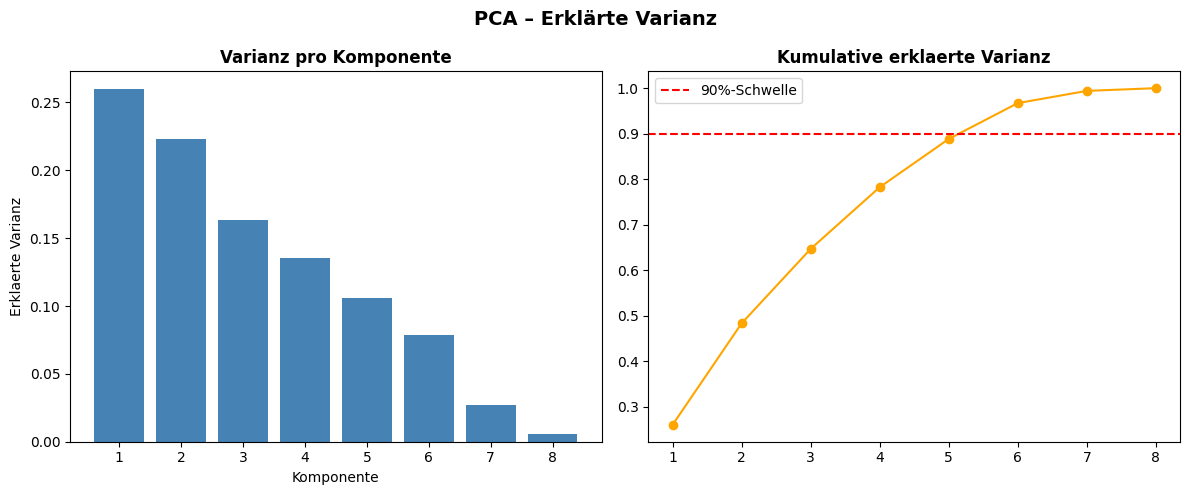

  PC1: 26.0% Varianz | kumulativ: 26.0%
  PC2: 22.3% Varianz | kumulativ: 48.3%
  PC3: 16.4% Varianz | kumulativ: 64.7%
  PC4: 13.6% Varianz | kumulativ: 78.2%
  PC5: 10.6% Varianz | kumulativ: 88.8%
  PC6: 7.9% Varianz | kumulativ: 96.7%
  PC7: 2.7% Varianz | kumulativ: 99.4%
  PC8: 0.6% Varianz | kumulativ: 100.0%
-> 6 Komponenten erklaeren >= 90% der Varianz


In [19]:
# == PCA-ANALYSE ==
pca = PCA()
pca.fit(X_train_scaled)
explained_var_ratio = pca.explained_variance_ratio_
cumsum_var = np.cumsum(explained_var_ratio)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('PCA – Erklärte Varianz', fontsize=14, fontweight='bold')
axes[0].bar(range(1, len(explained_var_ratio)+1), explained_var_ratio, color='steelblue')
axes[0].set_xlabel('Komponente'); axes[0].set_ylabel('Erklaerte Varianz')
axes[0].set_title('Varianz pro Komponente', fontweight='bold')
axes[1].plot(range(1, len(cumsum_var)+1), cumsum_var, marker='o', color='orange')
axes[1].axhline(0.90, color='red', linestyle='--', label='90%-Schwelle')
axes[1].set_title('Kumulative erklaerte Varianz', fontweight='bold'); axes[1].legend()
plt.tight_layout(); plt.savefig('pca_analyse.png', dpi=150, bbox_inches='tight'); plt.show()

n_90 = np.argmax(cumsum_var >= 0.90) + 1
for i, (ev, cv) in enumerate(zip(explained_var_ratio, cumsum_var), 1):
    print(f'  PC{i}: {ev:.1%} Varianz | kumulativ: {cv:.1%}')
print(f'-> {n_90} Komponenten erklaeren >= 90% der Varianz')

<a id='teil6'></a>
## Teil 6 – Finales Modell & Deployment

**Produktionsmodell: Random Forest (n_estimators=100)**  
Begründung: Höchster R² (0.806), kein TensorFlow-Stack nötig, interpretierbar via Feature Importance.

In [20]:
# == FINALES MODELL: RANDOM FOREST (n=100) ==
best_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
best_rf.fit(X_train_scaled, y_train_clean)
y_pred_final = best_rf.predict(X_test_scaled)

r2_final   = r2_score(y_test, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
mae_final  = mean_absolute_error(y_test, y_pred_final)

print(f'Random Forest (n=100): R2={r2_final:.4f} | RMSE={rmse_final:.4f} (~${rmse_final*100000:.0f}) | MAE={mae_final:.4f}')
print(f'Keras MLP (optimiert): R2={keras_r2:.4f}   | RMSE={keras_rmse:.4f}                | MAE={keras_mae:.4f}')

Random Forest (n=100): R2=0.8058 | RMSE=0.5045 (~$50451) | MAE=0.3257
Keras MLP (optimiert): R2=0.7835   | RMSE=0.5327                | MAE=0.3606


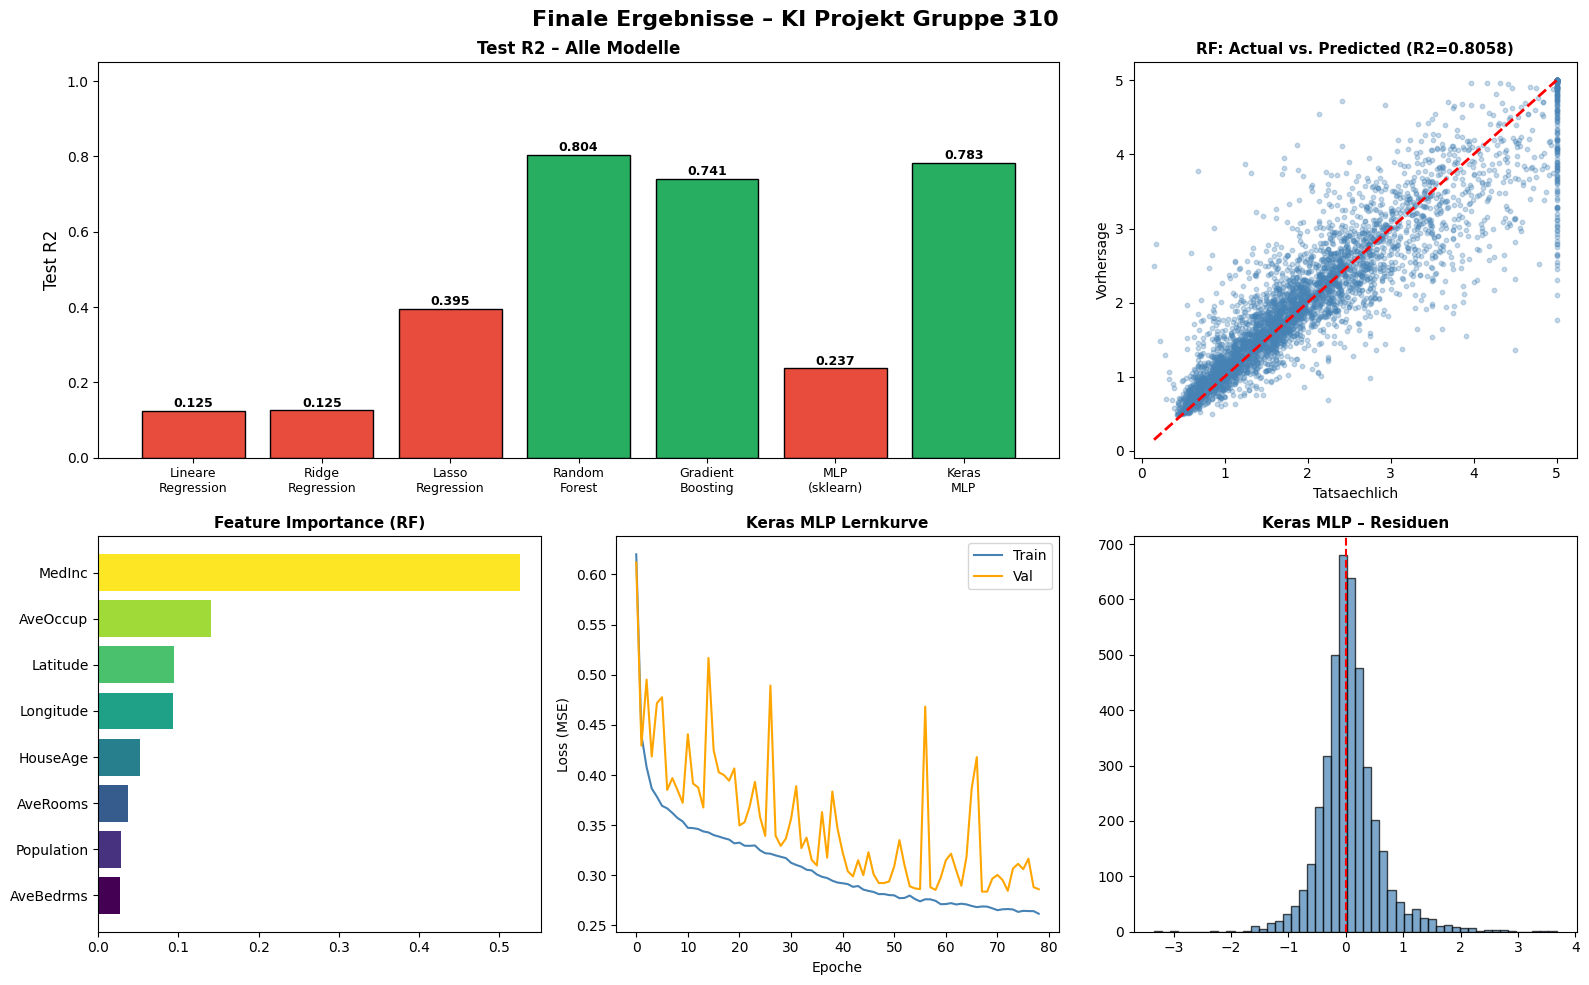

Abschluss-Visualisierung gespeichert.


In [21]:
# == ABSCHLUSS-VISUALISIERUNG ==
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Finale Ergebnisse – KI Projekt Gruppe 310', fontsize=16, fontweight='bold')

ax1 = fig.add_subplot(2, 3, (1, 2))
all_names = list(model_results.keys()) + ['Keras MLP']
all_r2    = [model_results[m]['Test_R2'] for m in model_results] + [keras_r2]
bar_colors = ['#e74c3c' if v < 0.5 else '#f39c12' if v < 0.7 else '#27ae60' for v in all_r2]
bars = ax1.bar(range(len(all_names)), all_r2, color=bar_colors, edgecolor='black')
ax1.set_xticks(range(len(all_names)))
ax1.set_xticklabels([n.replace(' ', '\n') for n in all_names], fontsize=9)
ax1.set_ylabel('Test R2', fontsize=12); ax1.set_ylim(0, 1.05)
ax1.set_title('Test R2 – Alle Modelle', fontsize=12, fontweight='bold')
for bar, val in zip(bars, all_r2):
    ax1.text(bar.get_x() + bar.get_width()/2, val+0.01, f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

ax2 = fig.add_subplot(2, 3, 3)
ax2.scatter(y_test, y_pred_final, alpha=0.3, s=10, c='steelblue')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
ax2.set_title(f'RF: Actual vs. Predicted (R2={r2_final:.4f})', fontsize=11, fontweight='bold')
ax2.set_xlabel('Tatsaechlich'); ax2.set_ylabel('Vorhersage')

ax3 = fig.add_subplot(2, 3, 4)
fi = pd.Series(best_rf.feature_importances_, index=feature_names).sort_values()
ax3.barh(fi.index, fi.values, color=plt.cm.viridis(np.linspace(0, 1, len(fi))))
ax3.set_title('Feature Importance (RF)', fontsize=11, fontweight='bold')

ax4 = fig.add_subplot(2, 3, 5)
ax4.plot(final_history.history['loss'],     label='Train', color='steelblue')
ax4.plot(final_history.history['val_loss'], label='Val',   color='orange')
ax4.set_xlabel('Epoche'); ax4.set_ylabel('Loss (MSE)')
ax4.set_title('Keras MLP Lernkurve', fontsize=11, fontweight='bold'); ax4.legend()

ax5 = fig.add_subplot(2, 3, 6)
ax5.hist(residuals, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax5.axvline(0, color='red', linestyle='--')
ax5.set_title('Keras MLP – Residuen', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('finale_ergebnisse.png', dpi=150, bbox_inches='tight')
plt.show()
print('Abschluss-Visualisierung gespeichert.')

In [23]:
# == MODELL SPEICHERN & DEPLOYMENT-DEMO ==
model_package = {
    'model': best_rf, 'scaler': scaler, 'feature_names': feature_names,
    'metrics': {'r2': r2_final, 'rmse': rmse_final, 'mae': mae_final},
    'best_hp': {'arch': best_arch, 'lr': fixed_lr, 'act': fixed_act,
                'batch': best_batch, 'dropout': best_dropout},
}
joblib.dump(model_package, 'best_model_rf.pkl')
joblib.dump(scaler,        'scaler.pkl')
final_keras_model.save('best_keras_mlp.keras')
print('Gespeichert: best_model_rf.pkl | scaler.pkl | best_keras_mlp.keras')

# Deployment-Demo: Vorhersage fuer 5 Beispiel-Haeuser
loaded       = joblib.load('best_model_rf.pkl')
sample_preds = loaded['model'].predict(loaded['scaler'].transform(X_test.iloc[:5]))

print('\nVorhersagen fuer 5 Beispiel-Haeuser:')
print(f'{"Haus #":<8} {"Tatsaechlich":>14} {"Vorhersage":>12} {"Abweichung":>12}')
print('-'*50)
for i, (true, pred) in enumerate(zip(y_test.iloc[:5], sample_preds)):
    print(f'{i+1:<8} ${true*100000:>12,.0f} ${pred*100000:>11,.0f} ${(pred-true)*100000:>+11,.0f}')

print()
print('=' * 60)
print('PROJEKT-ZUSAMMENFASSUNG - KI GRUPPE 310')
print('=' * 60)
print(f'Datensatz: California Housing | 20.640 Instanzen | 8 Features')
print(f'Preprocessing: IQR-Outlier (Faktor 3.0) + StandardScaler')
print()
print('MODELLVERGLEICH (Test R2):')
print(f'  Lineare Regression : {lin_r2:.4f}  (Baseline)')
print(f'  Keras MLP (opt.)   : {keras_r2:.4f}')
print(f'  Random Forest      : {r2_final:.4f}  <- PRODUKTIONSMODELL')
print()
print(f'BESTE KERAS-HP: Arch={best_arch} | LR={fixed_lr} | Act={fixed_act}')
print(f'  Batch={best_batch} | Dropout={best_dropout} | EarlyStopping(patience=10)')
print()
print('WICHTIGSTE FEATURES: MedInc (~52%) | AveOccup (~14%) | Lat/Lon (~19%)')
print('=' * 60)

Gespeichert: best_model_rf.pkl | scaler.pkl | best_keras_mlp.keras

Vorhersagen fuer 5 Beispiel-Haeuser:
Haus #     Tatsaechlich   Vorhersage   Abweichung
--------------------------------------------------
1        $      47,700 $     49,993 $     +2,293
2        $      45,800 $     69,626 $    +23,826
3        $     500,001 $    483,934 $    -16,067
4        $     218,600 $    258,400 $    +39,800
5        $     278,000 $    230,501 $    -47,499

PROJEKT-ZUSAMMENFASSUNG - KI GRUPPE 310
Datensatz: California Housing | 20.640 Instanzen | 8 Features
Preprocessing: IQR-Outlier (Faktor 3.0) + StandardScaler

MODELLVERGLEICH (Test R2):
  Lineare Regression : 0.1253  (Baseline)
  Keras MLP (opt.)   : 0.7835
  Random Forest      : 0.8058  <- PRODUKTIONSMODELL

BESTE KERAS-HP: Arch=[128, 64] | LR=0.1 | Act=sigmoid
  Batch=16 | Dropout=0.0 | EarlyStopping(patience=10)

WICHTIGSTE FEATURES: MedInc (~52%) | AveOccup (~14%) | Lat/Lon (~19%)
